# Python Lesson 45: Sigmoid Function

**Concept page:** `wiki/concepts/sigmoid-function.md` · **Area:** ml-connection

**You will be able to:**
- implement a numerically stable sigmoid
- verify σ' = σ(1−σ)
- use it as a probability output

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Definition and plot

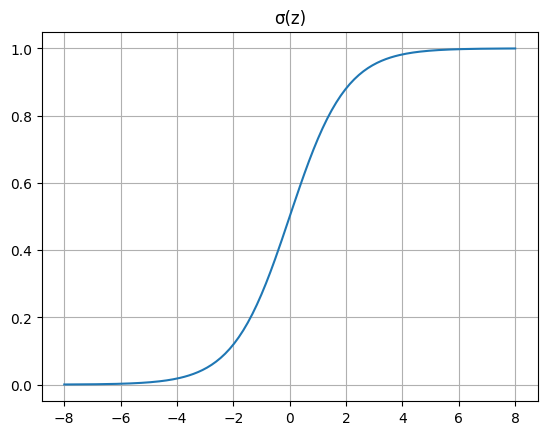

[0.  0.5 1. ]


In [2]:
def sigmoid(z):
    z=np.asarray(z,float); out=np.empty_like(z); pos=z>=0
    out[pos]=1/(1+np.exp(-z[pos])); e=np.exp(z[~pos]); out[~pos]=e/(1+e); return out
z=np.linspace(-8,8,200); plt.plot(z,sigmoid(z)); plt.grid(True); plt.title("σ(z)"); plt.show()
print(sigmoid([-1000,0,1000]))

## 2. Derivative σ(1−σ)

In [3]:
z0=0.7; h=1e-6; print((sigmoid(z0+h)-sigmoid(z0-h))/(2*h), sigmoid(z0)*(1-sigmoid(z0)))
zz=sp.symbols('z'); s=1/(1+sp.exp(-zz)); print(sp.simplify(sp.diff(s,zz)-s*(1-s)))

0.22171287328287548 0.22171287329310904
0


## 3. As a probability of a class

In [4]:
w,b=np.array([1.,1.]),-1.5
X=np.array([[0,0],[1,0],[0,1],[1,1],[2,2]]); print(np.round(sigmoid(X@w+b),3))   # AND-like perceptron

[0.182 0.378 0.378 0.622 0.924]


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Powers (Grade 11 basic ch. 2) and e^x (Grade 12 basic ch. 3) are the prerequisites for σ(z)=1/(1+e^{-z}).

In [5]:
print(np.exp(-1.0))

0.36787944117144233


## Exercises

**Exercise 1.** Evaluate σ at 0, 2, -2 and verify σ(-z)=1-σ(z).

In [6]:
# your code here

**Exercise 2.** Plot σ'(z) and find its maximum (0.25 at z=0).

In [7]:
# your code here

## Solutions
*(Try the exercises first!)*

In [8]:
# Solution 1
assert np.allclose(sigmoid([-2,2]),[1-sigmoid(2),sigmoid(2)])

In [9]:
# Solution 2
zz=np.linspace(-6,6,1201); d=sigmoid(zz)*(1-sigmoid(zz)); print(d.max(),zz[d.argmax()]); assert abs(d.max()-0.25)<1e-9

0.25 0.0
